In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhilroxtomar/brain-tumor-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-segmentation' dataset.
Path to dataset files: /kaggle/input/brain-tumor-segmentation


In [3]:
def load_data(data_path, img_size=(256, 256)):

    images = []
    masks = []

    # Define paths
    images_dir = os.path.join(data_path, 'images')
    masks_dir = os.path.join(data_path, 'masks')

    image_files = sorted(os.listdir(images_dir))

    for file_name in image_files:
        img_path = os.path.join(images_dir, file_name)
        mask_path = os.path.join(masks_dir, file_name)

        if os.path.exists(mask_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is not None and mask is not None:
                # Resize
                img = cv2.resize(img, img_size)
                mask = cv2.resize(mask, img_size)

                images.append(img)
                masks.append(mask)

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    # Normalize pixels
    images = images / 255.0
    masks = masks / 255.0
    masks = (masks > 0.5).astype(np.float32)

    #channel dimension (H, W, 1)
    images = np.expand_dims(images, axis=-1)
    masks = np.expand_dims(masks, axis=-1)

    return images, masks

images, masks = load_data(path)

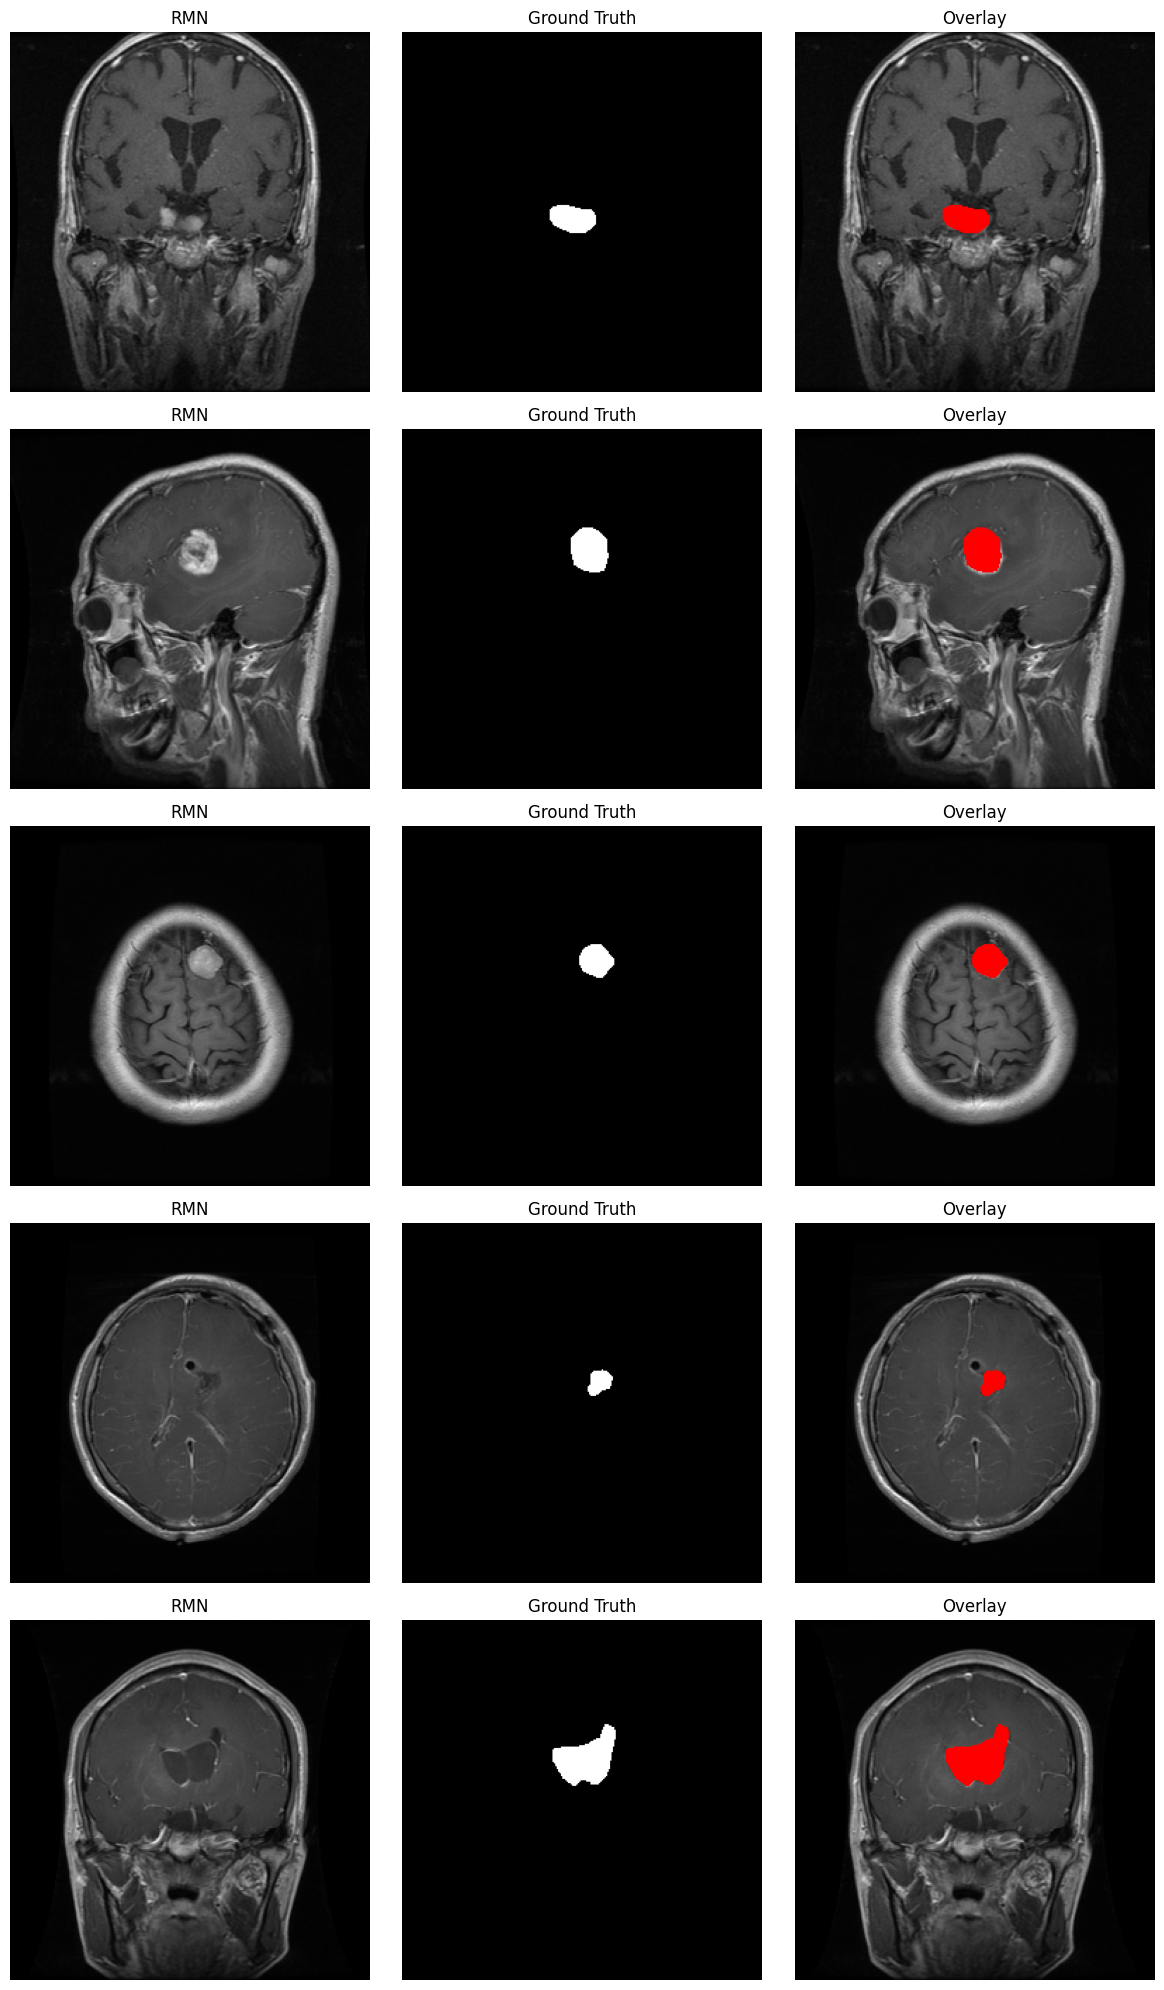

In [4]:
def visualize_data_samples(images, masks, num_samples=5):
    indices = np.random.choice(len(images), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    axes = np.atleast_2d(axes)

    for i, idx in enumerate(indices):
        img = images[idx].squeeze().astype(np.float32)
        mask = masks[idx].squeeze()

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        overlay = np.stack([img, img, img], axis=-1)
        overlay[mask > 0.5] = [1, 0, 0]

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title('RMN')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()
    return fig

fig = visualize_data_samples(images, masks, num_samples=5)


In [5]:
def conv_block(x, filters, kernel_size=3):
    """bloc conv"""
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x

In [6]:
def encoder_block(x, filters):
    """block encoder"""
    skip = conv_block(x, filters)
    x = layers.MaxPooling2D(pool_size=(2, 2))(skip)
    return x, skip

In [7]:
def decoder_block(x, skip, filters):
    """bloc decoder"""
    x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

In [8]:
def build_unet(input_shape=(256, 256, 1), num_classes=1):
    """arhitectura u-net"""
    inputs = layers.Input(shape=input_shape)


    x, skip1 = encoder_block(inputs, 64)
    x, skip2 = encoder_block(x, 128)
    x, skip3 = encoder_block(x, 256)
    x, skip4 = encoder_block(x, 512)

    x = conv_block(x, 1024)

    x = decoder_block(x, skip4, 512)
    x = decoder_block(x, skip3, 256)
    x = decoder_block(x, skip2, 128)
    x = decoder_block(x, skip1, 64)

    outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

In [9]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    """Coeficient Dice"""
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Dice loss"""
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    """Combined Dice loss + Binary Crossentropy"""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

def iou_metric(y_true, y_pred, smooth=1e-6):
    """Metrica IoU"""
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [10]:
images, masks = load_data(path)
print(f"Loaded {len(images)} images and masks")
print(f"Image shape: {images.shape}, Mask shape: {masks.shape}")

#data split: 70/15/15%
X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Loaded 3064 images and masks
Image shape: (3064, 256, 256, 1), Mask shape: (3064, 256, 256, 1)
Train: 2144, Val: 460, Test: 460


In [11]:
model = build_unet(input_shape=(256, 256, 1))
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coef, iou_metric, 'binary_accuracy']
)

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [12]:
callbacks = [
    ModelCheckpoint(
        'checkpoint_MRI.keras',
        save_best_only=True,
        monitor='val_dice_coef',
        mode='max'
        ),

    EarlyStopping(
        patience=15,
        monitor='val_dice_coef',
        mode='max',
        restore_best_weights=True
        ),

    ReduceLROnPlateau(
        factor=0.5,
        patience=5,
        monitor='val_dice_coef',
        mode='max',
        min_lr=1e-7
        )

]

In [13]:
print("\nTraining model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)


Training model...
Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - binary_accuracy: 0.7883 - dice_coef: 0.0504 - iou_metric: 0.0259 - loss: 1.4307 - val_binary_accuracy: 0.9826 - val_dice_coef: 0.0296 - val_iou_metric: 0.0150 - val_loss: 1.3478 - learning_rate: 1.0000e-04
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 127s 945ms/step - binary_accuracy: 0.9767 - dice_coef: 0.1409 - iou_metric: 0.0761 - loss: 1.0051 - val_binary_accuracy: 0.8698 - val_dice_coef: 0.0291 - val_iou_metric: 0.0148 - val_loss: 1.3322 - learning_rate: 1.0000e-04
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 126s 943ms/step - binary_accuracy: 0.9809 - dice_coef: 0.2057 - iou_metric: 0.1151 - loss: 0.9061 - val_binary_accuracy: 0.8330 - val_dice_coef: 0.0199 - val_iou_metric: 0.0101 - val_loss: 1.3726 - learning_rate: 1.0000e-04
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 129s 960ms/step - binary_accuracy: 0.9850 - dice_coef: 0.2731 - iou_metric: 0.1590 - loss: 0.8145 - val_binary_accuracy: 0.9618 - val_dice_coef: 0.1368 

In [14]:
print("\nEvaluare pe datele de test")
test_results = model.evaluate(X_test, y_test, verbose=1)
print(f"Coeficient Dice: {test_results[1]:.4f}")
print(f"Metrica IoU: {test_results[2]:.4f}")
print(f"Accuracy: {test_results[3]:.4f}")


Evaluare pe datele de test
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 628ms/step - binary_accuracy: 0.9943 - dice_coef: 0.8165 - iou_metric: 0.6911 - loss: 0.2157
Coeficient Dice: 0.8099
Metrica IoU: 0.6821
Accuracy: 0.9942


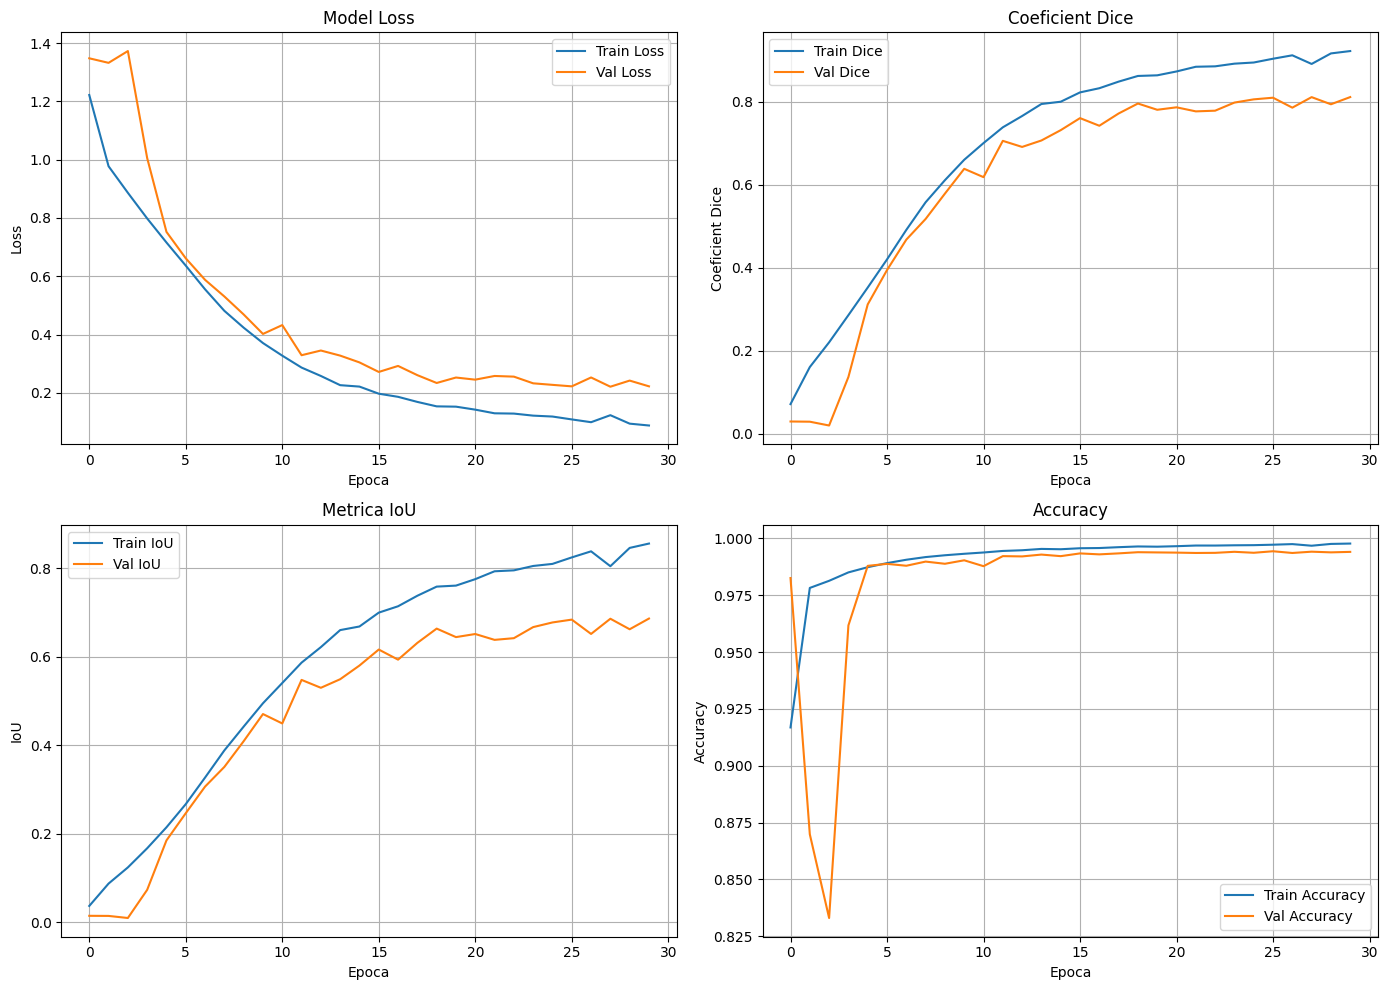

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoca')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Dice Coefficient
axes[0, 1].plot(history.history['dice_coef'], label='Train Dice')
axes[0, 1].plot(history.history['val_dice_coef'], label='Val Dice')
axes[0, 1].set_title('Coeficient Dice')
axes[0, 1].set_xlabel('Epoca')
axes[0, 1].set_ylabel('Coeficient Dice')
axes[0, 1].legend()
axes[0, 1].grid(True)

# IoU Metric
axes[1, 0].plot(history.history['iou_metric'], label='Train IoU')
axes[1, 0].plot(history.history['val_iou_metric'], label='Val IoU')
axes[1, 0].set_title('Metrica IoU')
axes[1, 0].set_xlabel('Epoca')
axes[1, 0].set_ylabel('IoU')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Binary Accuracy
axes[1, 1].plot(history.history['binary_accuracy'], label='Train Accuracy')
axes[1, 1].plot(history.history['val_binary_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('Accuracy')
axes[1, 1].set_xlabel('Epoca')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

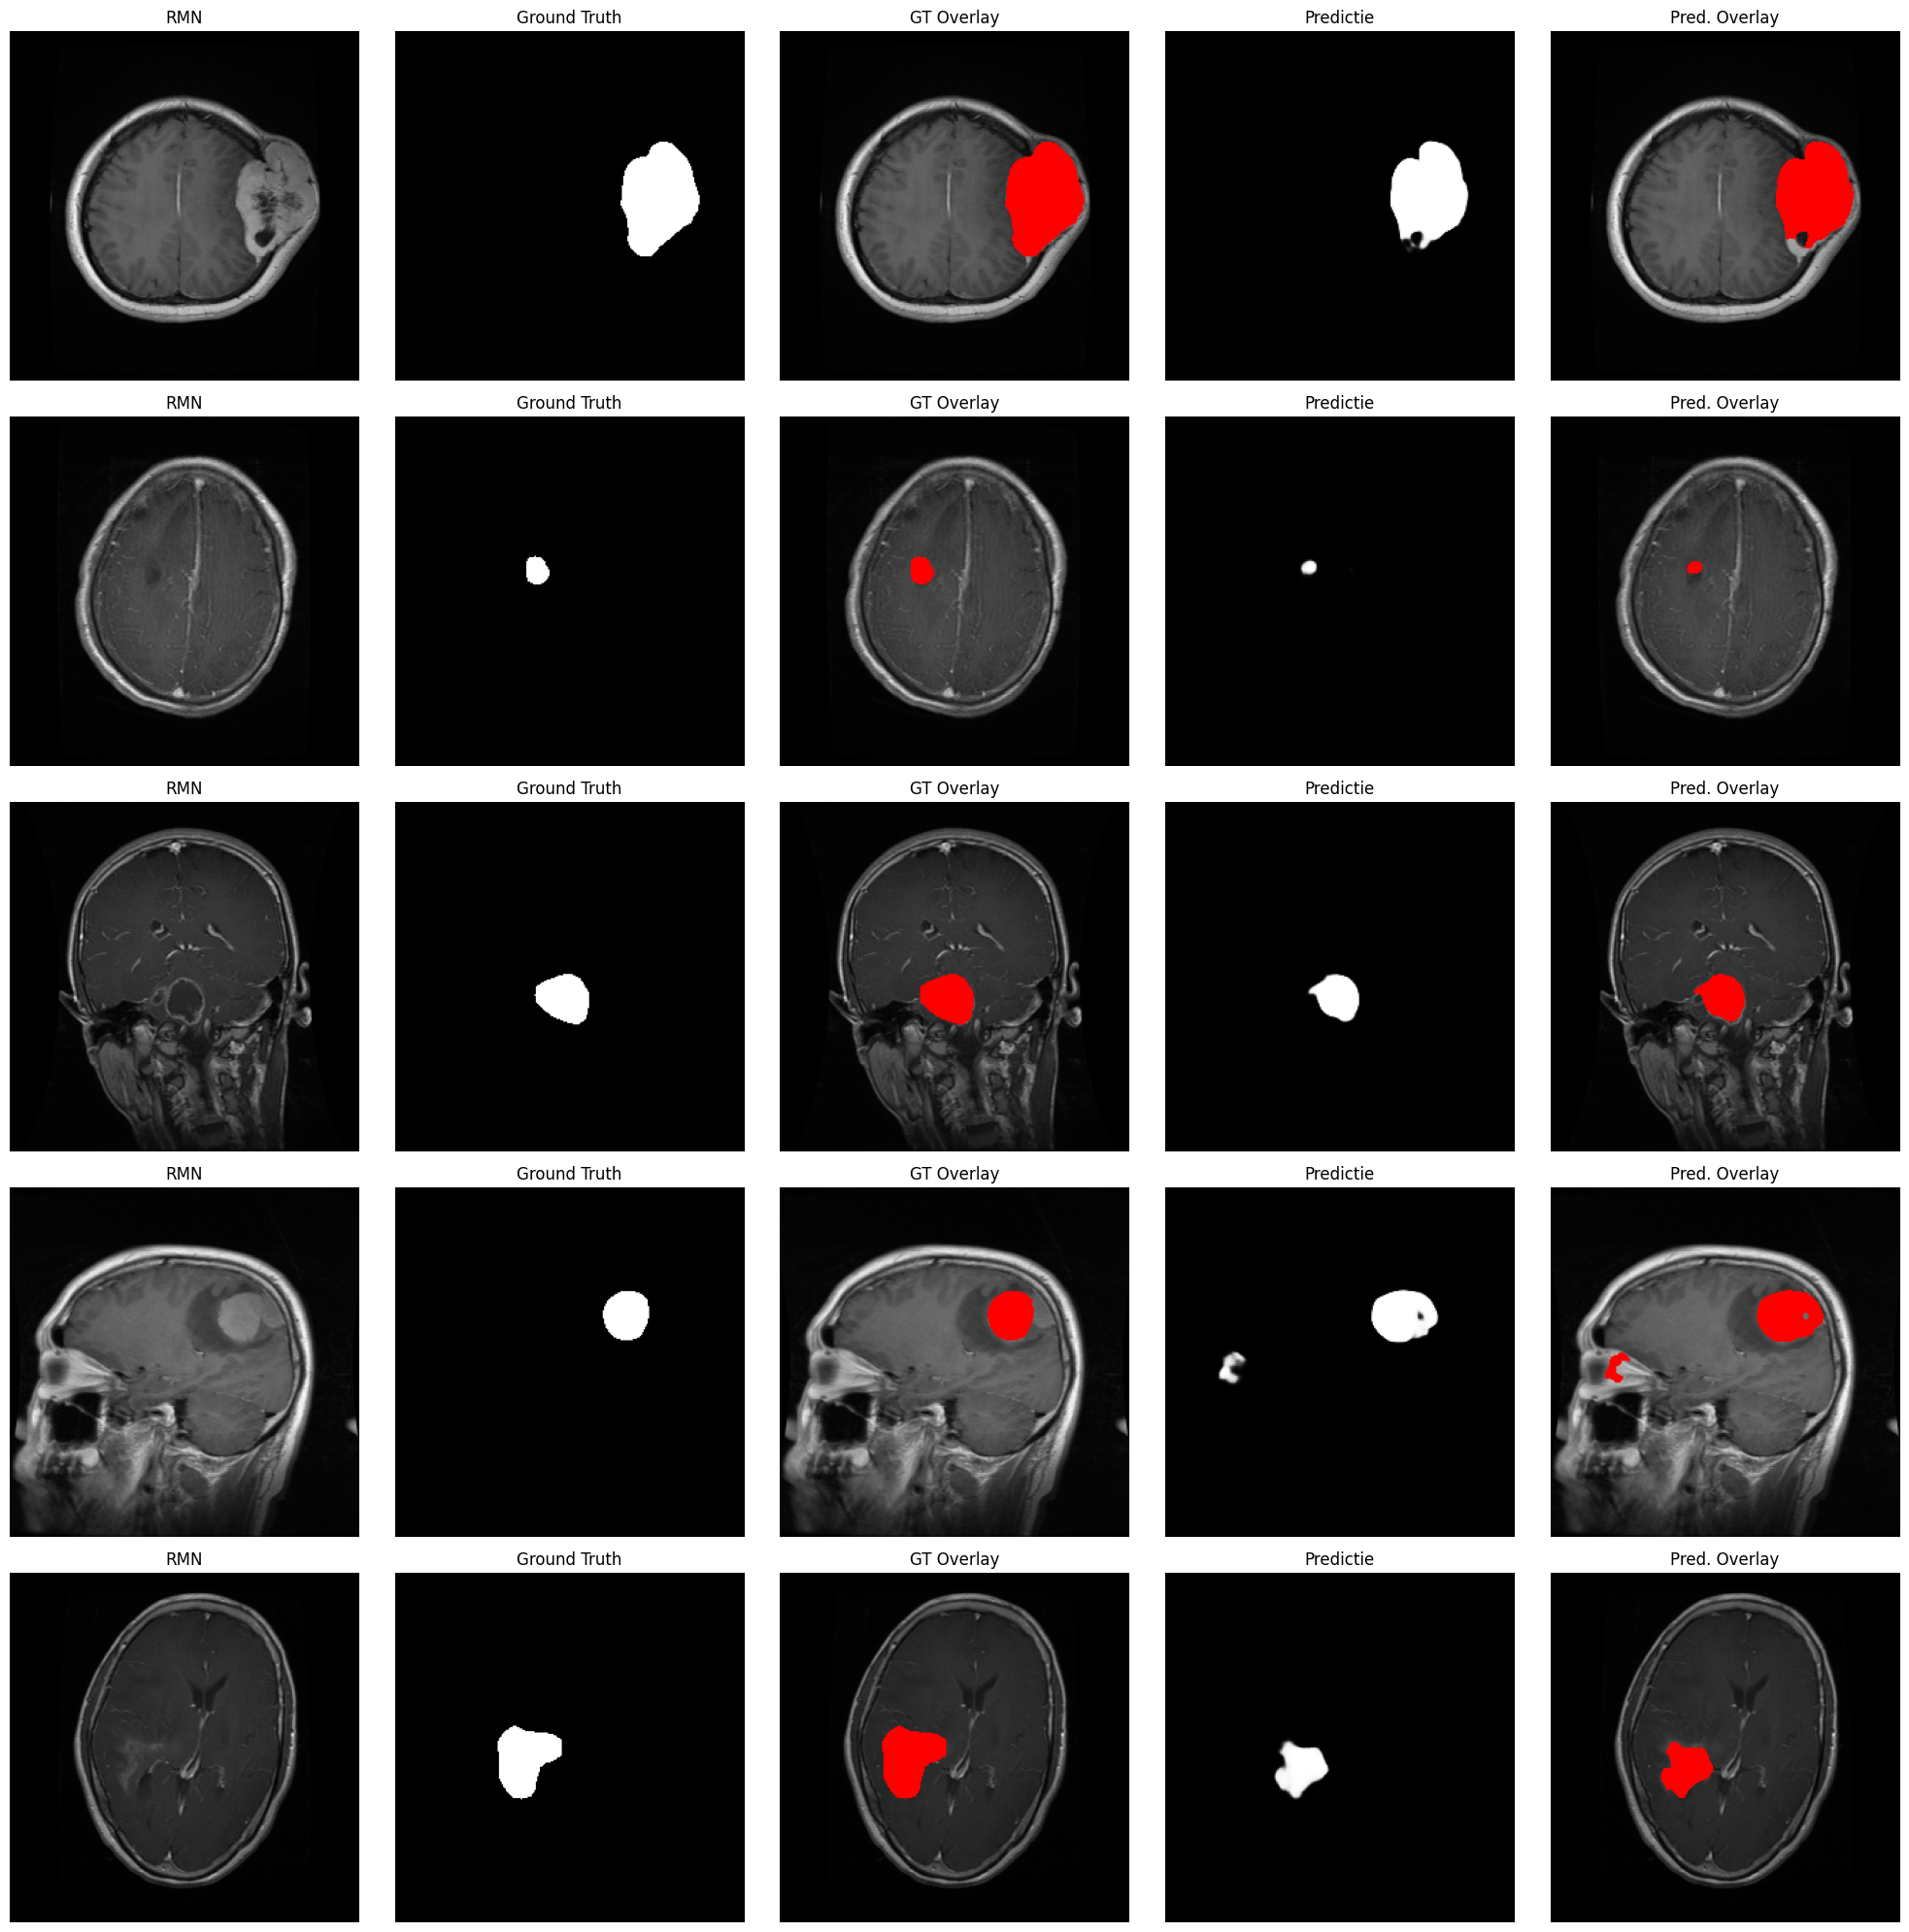

In [16]:
def visualize_predictions(model, images, masks, num_samples=3):
    indices = np.random.choice(len(images), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))

    for i, idx in enumerate(indices):
        img = images[idx].squeeze()
        true_mask = masks[idx].squeeze()
        pred_mask = model.predict(np.expand_dims(images[idx], 0), verbose=0)[0].squeeze()

        true_overlay = np.stack([img, img, img], axis=-1)
        true_overlay[:, :, 0] = np.where(true_mask > 0.5, 1.0, true_overlay[:, :, 0])
        true_overlay[:, :, 1] = np.where(true_mask > 0.5, 0.0, true_overlay[:, :, 1])
        true_overlay[:, :, 2] = np.where(true_mask > 0.5, 0.0, true_overlay[:, :, 2])

        pred_overlay = np.stack([img, img, img], axis=-1)
        pred_overlay[:, :, 0] = np.where(pred_mask > 0.5, 1.0, pred_overlay[:, :, 0])
        pred_overlay[:, :, 1] = np.where(pred_mask > 0.5, 0.0, pred_overlay[:, :, 1])
        pred_overlay[:, :, 2] = np.where(pred_mask > 0.5, 0.0, pred_overlay[:, :, 2])

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title('RMN')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(true_overlay)
        axes[i, 2].set_title('GT Overlay')
        axes[i, 2].axis('off')

        axes[i, 3].imshow(pred_mask, cmap='gray')
        axes[i, 3].set_title('Predictie')
        axes[i, 3].axis('off')

        axes[i, 4].imshow(pred_overlay)
        axes[i, 4].set_title('Pred. Overlay')
        axes[i, 4].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, X_test, y_test, num_samples=5)


In [17]:
model_save_path = 'MRI_1530.keras'
model.save(model_save_path)